# Text Summarization using LangChain

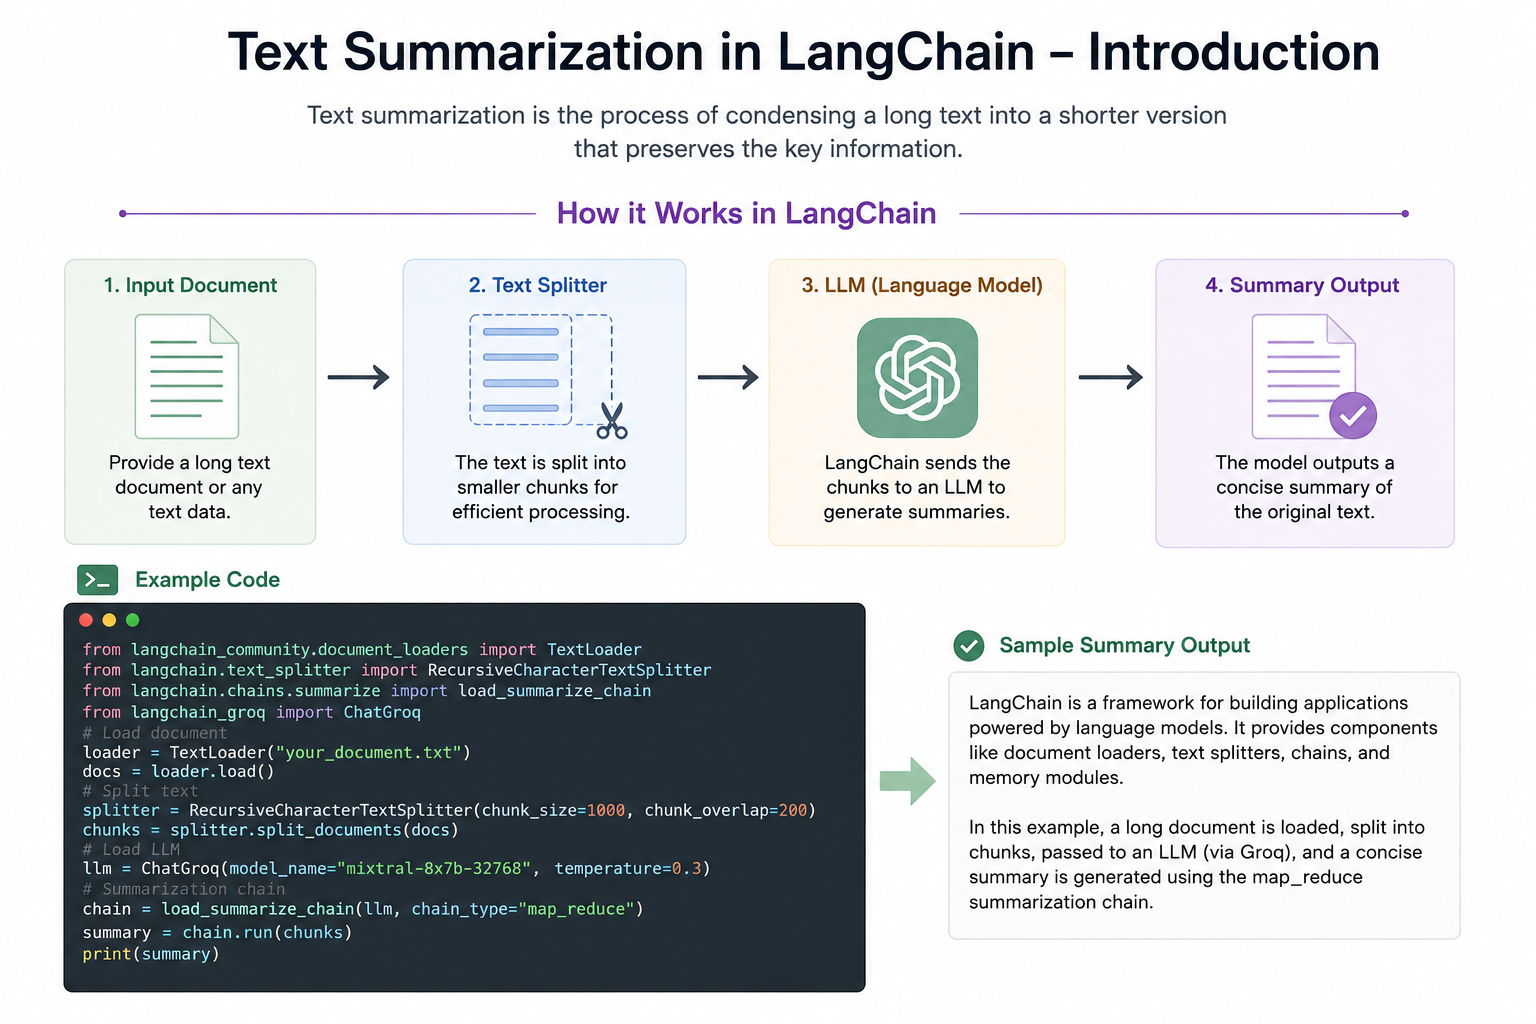

https://reference.langchain.com/python/langchain/agents/middleware/summarization


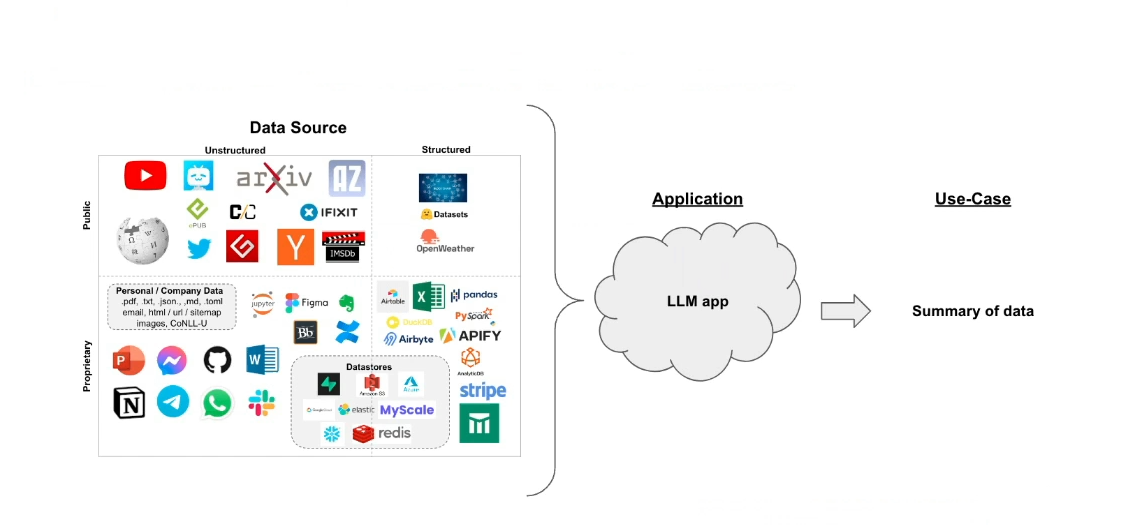

## Types of Summarization
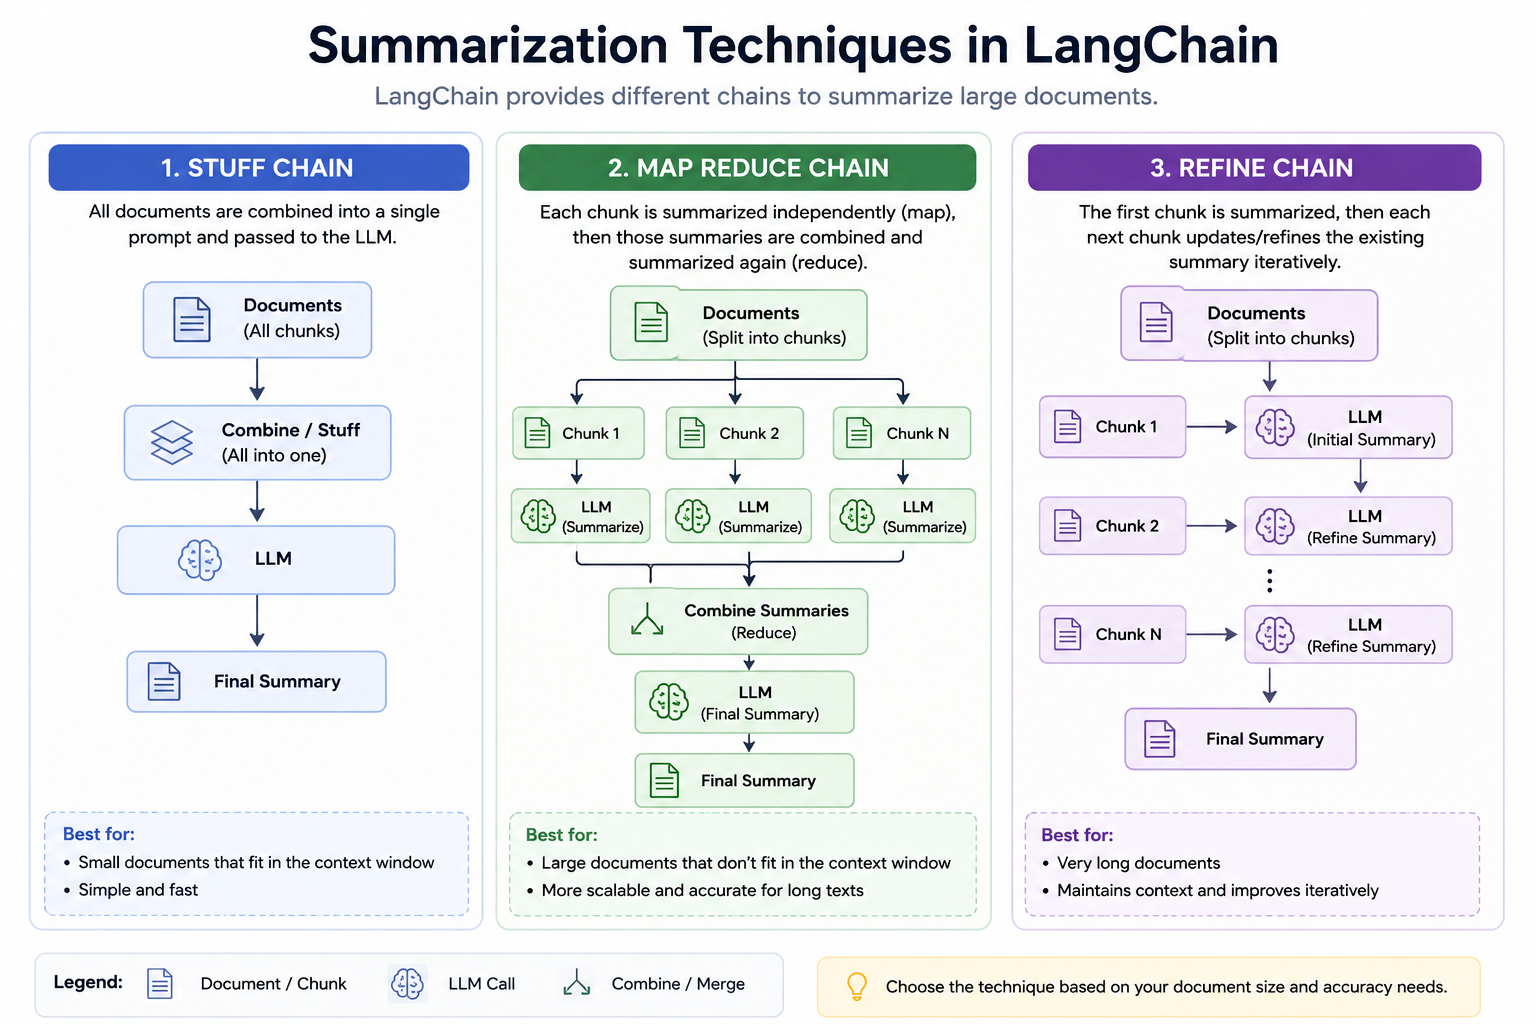

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
api_key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(groq_api_key=api_key, model = "llama-3.1-8b-instant")
llm

c:\Users\Uditya\anaconda3\envs\genai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000027B41CBCE90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000027B41D6AC90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

In [4]:
speech = """
It is an honour to speak to you today about a vision that can transform our lives and our nation. When we think of building a strong future, we must look at the incredible power hidden within the youth. As Dr. A.P.J. Abdul Kalam beautifully said, "Dream, dream, dream. Dreams transform into thoughts and thoughts result in action."Dreams are not what you see in your sleep; they are the things that do not let you sleep. To achieve greatness, every individual must build their life on four essential pillars.The first pillar is having a great aim. Small aim is a crime; you must have a great global vision. Do not fear big challenges. Set your sights high, because when you aim for the stars, you break the chains of mediocrity.The second pillar is continuously acquiring knowledge. Knowledge is a unique tool. It gives you creativity, creativity leads to thinking, thinking provides knowledge, and knowledge makes you great. Never stop being a student of life. Read books, observe the world, and learn from every person you meet.The third pillar is hard work. No great achievement is born out of comfort. Dr. Kalam often reminded us that if you want to shine like a sun, you must first burn like a sun. Sweat, dedication, and relentless effort are the only keys to unlocking your true potential.The fourth and final pillar is perseverance and managing failure. Life is a journey filled with obstacles. You will face defeats, but defeat should not defeat you. You must become the captain of your problems, defeat the difficulties, and succeed. True leaders take responsibility for failures and share the rewards of success with their teams.India is a land of a billion people, and our greatest strength is our youth. If a billion people ignite their minds, no power on earth can stop our progress. We must work together to create a prosperous, healthy, and secure nation. We must move from asking "What can the country do for me?" to asking "What can I do for my country?"Let us leave this room today with a promise to ourselves. Let us vow to fly with the wings of fire, to work with integrity, and to never give up on our righteous paths. Together, we can take our nation to the pinnacle of success.Thank you, and Jai Hind!
 """

In [5]:
chat_message = [
    SystemMessage(content = "You are expert in summarizing the speech"),
    HumanMessage(content=f"Please provide a short and concise summary of the follow speech:\n Text: {speech}")

]


In [6]:
llm.get_num_tokens(speech)

c:\Users\Uditya\anaconda3\envs\genai\Lib\site-packages\langchain_core\language_models\base.py:447: UserWarning: Using fallback GPT-2 tokenizer for token counting. Token counts may be inaccurate for non-GPT-2 models. For accurate counts, use a model-specific method if available.
  return len(self.get_token_ids(text))


478

In [7]:
llm.invoke(chat_message)

AIMessage(content="Here is a short and concise summary of the speech:\n\nThe speaker emphasizes the importance of youth in transforming India's future. They outline four essential pillars to achieve greatness: \n\n1. Having a great aim and vision\n2. Continuously acquiring knowledge\n3. Hard work and dedication\n4. Perseverance and managing failure\n\nThe speaker encourages the youth to work together to create a prosperous nation, shifting from a self-centered mindset to a nation-centered one. They conclude by urging the audience to vow to integrity, hard work, and perseverance, ultimately taking India to the pinnacle of success.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 120, 'prompt_tokens': 526, 'total_tokens': 646, 'completion_time': 0.179255182, 'completion_tokens_details': None, 'prompt_time': 0.049556529, 'prompt_tokens_details': None, 'queue_time': 0.062070021, 'total_time': 0.228811711}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerp

In [8]:
llm.invoke(chat_message).content

'The speech emphasizes the importance of four essential pillars to achieve greatness:\n\n1. Having a great aim (vision) to break free from mediocrity.\n2. Continuously acquiring knowledge to unlock creativity and potential.\n3. Hard work and dedication to achieve success.\n4. Perseverance and managing failure to overcome obstacles and take responsibility.\n\nThe speaker emphasizes the power of the youth and the potential of India to achieve greatness if they work together and focus on what they can contribute to their country.'

## Prompt Template Text Summarization

In [9]:
from langchain_classic.chains import LLMChain
from langchain_core.prompts import PromptTemplate
generictemplate = """
Write a summary of the following speech:
Speech:{speech}
Translate the precise summary to {language}

"""

prompt = PromptTemplate(
    input_variables=['speech', 'language'],
    template = generictemplate
)

prompt


PromptTemplate(input_variables=['language', 'speech'], input_types={}, partial_variables={}, template='\nWrite a summary of the following speech:\nSpeech:{speech}\nTranslate the precise summary to {language}\n\n')

In [10]:
complete_prompt = prompt.format(speech=speech, language = "French")

In [11]:
complete_prompt

'\nWrite a summary of the following speech:\nSpeech:\nIt is an honour to speak to you today about a vision that can transform our lives and our nation. When we think of building a strong future, we must look at the incredible power hidden within the youth. As Dr. A.P.J. Abdul Kalam beautifully said, "Dream, dream, dream. Dreams transform into thoughts and thoughts result in action."Dreams are not what you see in your sleep; they are the things that do not let you sleep. To achieve greatness, every individual must build their life on four essential pillars.The first pillar is having a great aim. Small aim is a crime; you must have a great global vision. Do not fear big challenges. Set your sights high, because when you aim for the stars, you break the chains of mediocrity.The second pillar is continuously acquiring knowledge. Knowledge is a unique tool. It gives you creativity, creativity leads to thinking, thinking provides knowledge, and knowledge makes you great. Never stop being a s

In [12]:
llm.get_num_tokens(complete_prompt)

500

In [13]:
llm_chain = LLMChain(llm = llm, prompt = prompt)
summary = llm_chain.invoke({'speech':speech, 'language':'Hindi'})
summary

C:\Users\Uditya\AppData\Local\Temp\ipykernel_4924\2192414600.py:1: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 2.0.0. Use `RunnableSequence, e.g., `prompt | llm`` instead.
  llm_chain = LLMChain(llm = llm, prompt = prompt)


{'speech': '\nIt is an honour to speak to you today about a vision that can transform our lives and our nation. When we think of building a strong future, we must look at the incredible power hidden within the youth. As Dr. A.P.J. Abdul Kalam beautifully said, "Dream, dream, dream. Dreams transform into thoughts and thoughts result in action."Dreams are not what you see in your sleep; they are the things that do not let you sleep. To achieve greatness, every individual must build their life on four essential pillars.The first pillar is having a great aim. Small aim is a crime; you must have a great global vision. Do not fear big challenges. Set your sights high, because when you aim for the stars, you break the chains of mediocrity.The second pillar is continuously acquiring knowledge. Knowledge is a unique tool. It gives you creativity, creativity leads to thinking, thinking provides knowledge, and knowledge makes you great. Never stop being a student of life. Read books, observe the 

# StuffDocumentChain Text Summarization

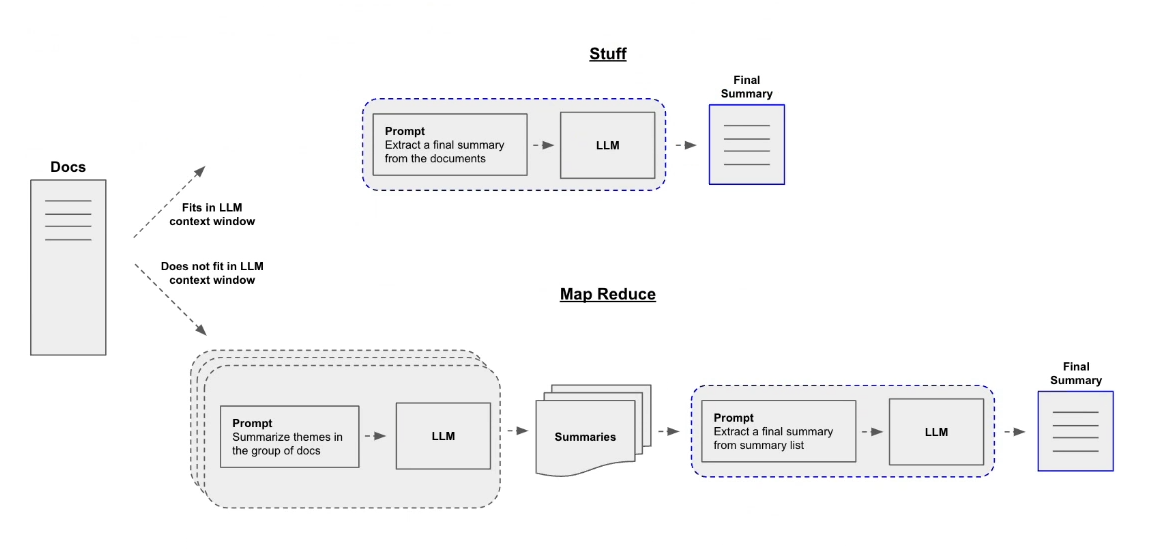

https://reference.langchain.com/python/langchain-classic/chains/combine_documents/stuff/StuffDocumentsChain

In [14]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("resume.pdf")
doc = loader.load_and_split()
# doc

C:\Users\Uditya\AppData\Local\Temp\ipykernel_4924\2151615733.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [15]:
template = """
Write a concise and short summary of the following speech,
speech:{text}

"""
prompt = PromptTemplate(input_variables=['text'],
                        template=template)

In [16]:
from langchain_classic.chains.summarize import load_summarize_chain

chain = load_summarize_chain(
    llm=llm,
    chain_type="stuff",
    prompt=prompt,
    verbose=True
)

output_summary = chain.run(doc)
print(output_summary)

C:\Users\Uditya\AppData\Local\Temp\ipykernel_4924\2594466928.py:10: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  output_summary = chain.run(doc)




> Entering new StuffDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:

Write a concise and short summary of the following speech,
speech:Uditya Narayan Tiwari
Jaunpur, Uttar Pradesh
 uditmerit@gmail.com LinkedIn /gtbGitHub
EDUCATION
VIT Bhopal University , Kothrikalan 2023 – Present
B.Tech - Computer Science Engineering with AI & ML - CGPA: 9.00 VIT Bhopal University
EXPERIENCE
Core Member, Matrix Media Club Jan 2025 – Jul 2025
Tech Team Member VIT Bhopal University
• Developed smart applications to improve communication between event hosts and clients.
T echnical Member, Microsoft Learn Student Chapter Apr 2025 – Apr 2026
Tech Team Member & Community Admin VIT Bhopal University
• Organized technical workshops and Hackathons for Microsoft technologies.
PROJECTS
NeuroLens A Knowledge Retrieval Engine | Python, LangChain, RAG, LLMs Jun 2026
• Developed an AI-powered knowledge retrieval system using Retrieval-Augmented Generation (RAG).
• Built semantic

## Map Reduce to Summarize Large Documents

In [17]:
loader = PyPDFLoader("Transformer.pdf")
docs = loader.load_and_split()

In [18]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

map_doc = RecursiveCharacterTextSplitter(chunk_size = 2000, chunk_overlap = 100).split_documents(docs)
# map_doc

In [19]:
len(map_doc)

28

In [20]:
map_chunk_prompt = """
Write a concise and short summary of the following document,
document:{text}

"""
map_prompt = PromptTemplate(input_variables=['text'],
                        template=map_chunk_prompt)

In [21]:
final_prompt = '''
Provide the final summary of the entire document with these important points.
add the original idea behind it with the flows of old models and how it overcome the old models.
document:{text}'''
final_prompt_temp = PromptTemplate(input_variables=['text'], template=final_prompt)
final_prompt_temp

PromptTemplate(input_variables=['text'], input_types={}, partial_variables={}, template='\nProvide the final summary of the entire document with these important points.\nadd the original idea behind it with the flows of old models and how it overcome the old models.\ndocument:{text}')

In [22]:
summary_chain = load_summarize_chain(llm = llm, chain_type ="map_reduce", map_prompt = map_prompt, combine_prompt = final_prompt_temp,verbose=True)

output = summary_chain.invoke(map_doc)
print(output)



> Entering new MapReduceDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:

Write a concise and short summary of the following document,
document:Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.edu
Łukasz Kaiser∗
Google Brain
lukaszkaiser@google.com
Illia Polosukhin∗ ‡
illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and decoder through a

# Refine Chain for Summarization

In [33]:
chain = load_summarize_chain(
    llm=llm,
    chain_type="refine",
    verbose=True
)

output_summary = chain.invoke(doc)
(output_summary)



> Entering new RefineDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
Write a concise summary of the following:


"Uditya Narayan Tiwari
Jaunpur, Uttar Pradesh
 uditmerit@gmail.com LinkedIn /gtbGitHub
EDUCATION
VIT Bhopal University , Kothrikalan 2023 – Present
B.Tech - Computer Science Engineering with AI & ML - CGPA: 9.00 VIT Bhopal University
EXPERIENCE
Core Member, Matrix Media Club Jan 2025 – Jul 2025
Tech Team Member VIT Bhopal University
• Developed smart applications to improve communication between event hosts and clients.
T echnical Member, Microsoft Learn Student Chapter Apr 2025 – Apr 2026
Tech Team Member & Community Admin VIT Bhopal University
• Organized technical workshops and Hackathons for Microsoft technologies.
PROJECTS
NeuroLens A Knowledge Retrieval Engine | Python, LangChain, RAG, LLMs Jun 2026
• Developed an AI-powered knowledge retrieval system using Retrieval-Augmented Generation (RAG).
• Built semantic search and vector em

{'input_documents': [Document(metadata={'producer': 'pdfTeX-1.40.26', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-06-15T05:10:08+00:00', 'author': '', 'keywords': '', 'moddate': '2026-06-15T05:10:08+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) kpathsea version 6.4.0', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Uditya Narayan Tiwari\nJaunpur, Uttar Pradesh\n uditmerit@gmail.com LinkedIn /gtbGitHub\nEDUCATION\nVIT Bhopal University , Kothrikalan 2023 – Present\nB.Tech - Computer Science Engineering with AI & ML - CGPA: 9.00 VIT Bhopal University\nEXPERIENCE\nCore Member, Matrix Media Club Jan 2025 – Jul 2025\nTech Team Member VIT Bhopal University\n• Developed smart applications to improve communication between event hosts and clients.\nT echnical Member, Microsoft Learn Student Chapter Apr 2025 – Apr 2026\nTech Team Member & Community Ad